# Exploration of DQN

In [5]:
import os
import pandas as pd
from src.utils.plotting import plot_learning_curve, plot_env_curves, plot_param_comparison

# I. Tuning update frequency

In [6]:
DATA_DIR = os.path.join("results", "data", "CartPole_DQN")

epss = [0.9993, 0.9996, 0.9999]
n_episodes = 300

dfs = []
for eps_decay in epss:
    eps_decay_str = str(eps_decay).replace(".", "")
    FILE_PATH = os.path.join(DATA_DIR, f"dqn_CartPole-v1_logs_nep{n_episodes}_eps{eps_decay_str}.csv")
    df = pd.read_csv(FILE_PATH)
    df["eps_decay"] = eps_decay
    dfs.append(df)
    print("len(df):", len(df))

df_combined = pd.concat(dfs, ignore_index=True)

len(df): 203540
len(df): 250883
len(df): 203540


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_param_comparison(
    df,
    metric="eval_reward",
    param="algo",
    save_path=None,
):
    """
    Plot mean ± std learning curves across seeds.

    Assumes:
    - one metric value logged per episode/evaluation
    - all seeds have same number of logged episodes
    - step counts may differ across seeds

    Args:
        df (pd.DataFrame):
            Must contain columns:
            ['seed', 'metric', 'value', param]

        metric (str):
            Metric to plot (e.g. "eval_reward")

        param (str):
            Column used for comparison/hue
            (e.g. "algo", "learning_rate")

        save_path (str or None):
            Optional path to save figure
    """

    plt.figure(figsize=(12, 8))

    # filter metric
    df_plot = df[df["metric"] == metric].copy()

    # create aligned episode/eval index
    df_plot["episode"] = (
        df_plot
        .groupby([param, "seed"])
        .cumcount()
    )
    eval_interval = 10
    df_plot["episode"] = df_plot["episode"] * eval_interval


    # palette = sns.color_palette(
    #     "flare",
    #     n_colors=df_plot[param].nunique()
    # )
    #palette = sns.color_palette("Spectral", as_cmap=True)
    palette = sns.color_palette()


    sns.lineplot(
        data=df_plot,
        x="episode",
        y="value",
        hue=param,
        errorbar="sd",
        palette=palette,
    )

    plt.title(f"{param} comparison", fontsize=18)
    plt.xlabel("Episode", fontsize=16)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=16)

    plt.legend(
        title=param,
        fontsize=12,
        title_fontsize=13,
    )

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Plot saved to: {save_path}")

    plt.show()
    plt.close()

/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_45855/1552266914.py:58: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(


Plot saved to: results/plots/CartPole_DQN_eps_decay_comparison.png


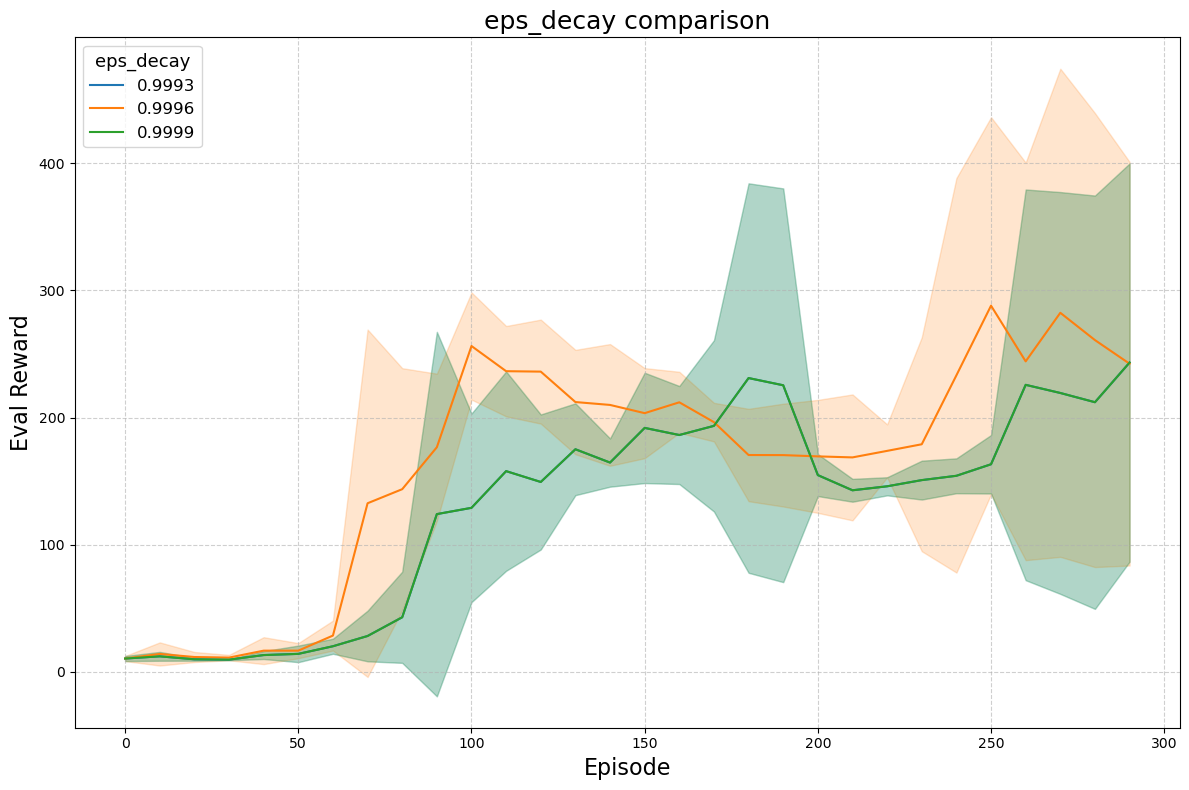

In [10]:
SAVE_PATH = os.path.join("results", "plots", "CartPole_DQN_eps_decay_comparison.png")
plot_param_comparison(df_combined, metric="eval_reward", param="eps_decay", save_path=SAVE_PATH)